In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#

In [29]:
x = 6 * np.random.rand(100,1)-3
y = 0.5 * x**2+1.5*x+2+np.random.rand(100,1)

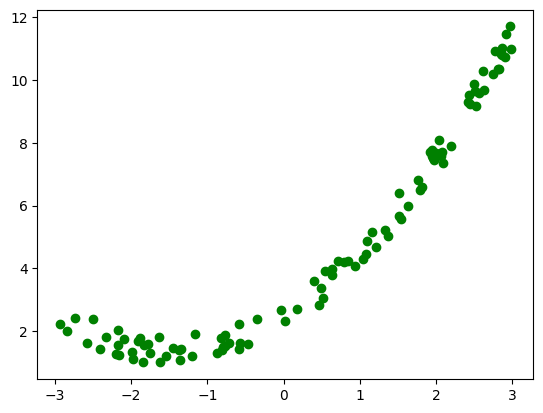

In [30]:
plt.scatter(x,y,color='g')
plt.show()

In [31]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [32]:
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()
regression_1.fit(xtrain,ytrain)

LinearRegression()

In [33]:
print(regression_1.coef_)

[[1.7939968]]


In [34]:
from sklearn.metrics import r2_score
score=r2_score(ytest,regression_1.predict(xtest))
print(score)

0.8316511608011731


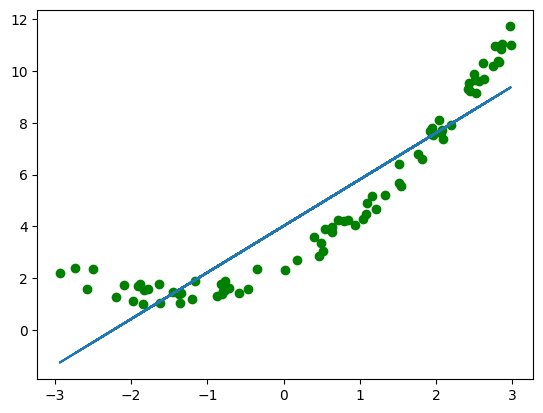

In [35]:
#creating bestfit line
plt.plot(xtrain,regression_1.predict(xtrain))
plt.scatter(xtrain,ytrain,color='g')
plt.show()

In [36]:
#lets apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)
pxtrain=poly.fit_transform(xtrain)
pxtest=poly.transform(xtest)

In [37]:
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()
regression_1.fit(pxtrain,ytrain)
from sklearn.metrics import r2_score
score=r2_score(ytest,regression_1.predict(pxtest))
print(score)

0.9936411791879552


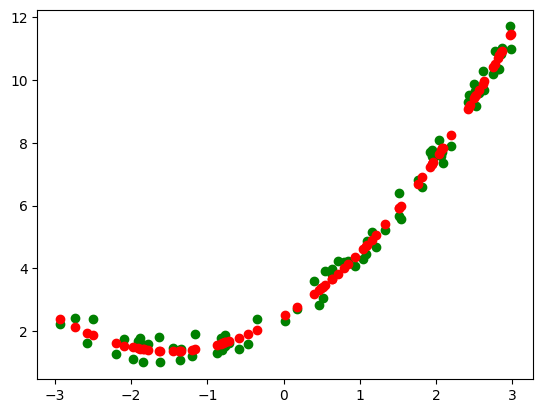

In [38]:
#creating polynomial bestfit line

plt.scatter(xtrain,ytrain,color='g')
plt.scatter(xtrain,regression_1.predict(pxtrain),color='r')
plt.show()

In [39]:
from sklearn.pipeline import Pipeline

In [40]:
def pipeline(degree):
    x_new=np.linspace(-3,3,200).reshape(200,1)
    polyf=PolynomialFeatures(degree=degree,include_bias=True)
    lregression=LinearRegression()
    poly_regression=Pipeline([
        ("polyf",polyf),
        ("lregression",lregression)
    ])
    poly_regression.fit(xtrain,ytrain)
    y_pred_new=poly_regression.predict(x_new)
    
    plt.plot(x_new, y_pred_new, "r", linewidth=3, label="Prediction line")
    plt.plot(xtrain, ytrain, "g.", label="Train data")
    plt.plot(xtest, ytest, "b.", label="Test data")

    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.show()


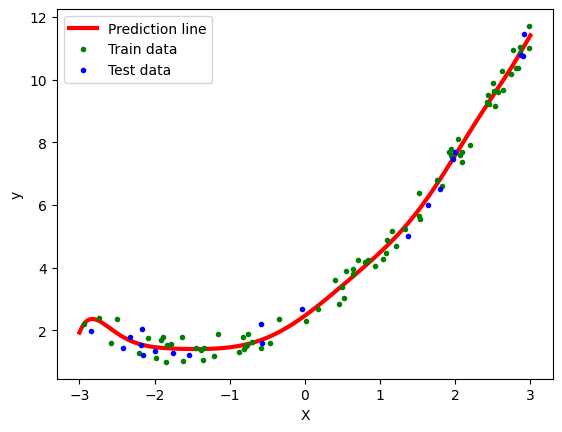

In [50]:
pipeline(12)